# 第二十八章：DALL-E 關鍵組件實作

本 notebook 實作 DALL-E 的核心組件，包括：
1. Discrete VAE（dVAE）的編碼器和解碼器
2. Gumbel-Softmax 重參數化
3. 稀疏注意力機制
4. 自迴歸 Transformer

**注意**：完整的 DALL-E 需要大量計算資源，這裡只展示核心概念的簡化版本。

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch 版本: {torch.__version__}")

PyTorch 版本: 2.9.0+cu126


## 1. Gumbel-Softmax 技巧

離散化操作（argmax）不可微分。Gumbel-Softmax 提供了一個可微分的近似方法。

In [2]:
def sample_gumbel(shape, eps=1e-10):
    """
    採樣 Gumbel(0, 1) 噪音
    使用逆變換採樣：g = -log(-log(u))，其中 u ~ Uniform(0, 1)
    """
    u = torch.rand(shape)
    return -torch.log(-torch.log(u + eps) + eps)

def gumbel_softmax(logits, tau=1.0, hard=False):
    """
    Gumbel-Softmax 採樣
    
    Args:
        logits: [batch, num_classes, ...] 未正規化的對數機率
        tau: 溫度參數，越低輸出越接近 one-hot
        hard: 是否使用 straight-through estimator
        
    Returns:
        如果 hard=False，返回軟分布
        如果 hard=True，返回 one-hot（但梯度通過軟分布傳遞）
    """
    # 採樣 Gumbel 噪音
    gumbels = sample_gumbel(logits.shape).to(logits.device)
    
    # 加入噪音並縮放
    y_soft = F.softmax((logits + gumbels) / tau, dim=1)
    
    if hard:
        # Straight-through estimator
        # 前向：使用 argmax
        # 反向：使用 softmax 的梯度
        index = y_soft.argmax(dim=1, keepdim=True)
        y_hard = torch.zeros_like(logits).scatter_(1, index, 1.0)
        # 這個技巧讓 y_hard 在前向時使用，但梯度通過 y_soft 傳遞
        return y_hard - y_soft.detach() + y_soft
    
    return y_soft

# 測試不同溫度的效果
logits = torch.randn(1, 5)  # 5 個類別
print(f"原始 logits: {logits}")
print(f"\n溫度 τ=1.0: {gumbel_softmax(logits, tau=1.0)}")
print(f"溫度 τ=0.5: {gumbel_softmax(logits, tau=0.5)}")
print(f"溫度 τ=0.1: {gumbel_softmax(logits, tau=0.1)}")
print(f"Hard 模式: {gumbel_softmax(logits, tau=0.5, hard=True)}")

原始 logits: tensor([[ 0.3367,  0.1288,  0.2345,  0.2303, -1.1229]])

溫度 τ=1.0: tensor([[0.4905, 0.0985, 0.2069, 0.0730, 0.1311]])
溫度 τ=0.5: tensor([[0.4093, 0.0476, 0.4735, 0.0594, 0.0102]])
溫度 τ=0.1: tensor([[5.1864e-08, 1.0000e+00, 3.8972e-11, 8.3076e-09, 1.2951e-13]])
Hard 模式: tensor([[0., 0., 0., 1., 0.]])


## 2. Discrete VAE (dVAE) 編碼器

編碼器將圖像壓縮為離散的潛在表示。

In [3]:
class ResidualBlock(nn.Module):
    """殘差塊，用於編碼器和解碼器"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 1)
        )
        
        # 如果通道數不同，需要投影
        self.shortcut = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        
    def forward(self, x):
        return self.shortcut(x) + self.block(x)


class DVAEEncoder(nn.Module):
    """
    dVAE 編碼器：將圖像編碼為離散 token
    
    輸入：256×256×3 圖像
    輸出：32×32 的離散 token 索引（每個位置 8192 種可能值）
    """
    def __init__(
        self,
        num_tokens: int = 8192,
        hidden_dim: int = 256,
        num_layers: int = 3,
        num_res_blocks: int = 2
    ):
        super().__init__()
        self.num_tokens = num_tokens
        
        # 初始卷積
        layers = [nn.Conv2d(3, hidden_dim, 7, padding=3)]
        
        # 下採樣層
        in_ch = hidden_dim
        for i in range(num_layers):
            out_ch = hidden_dim * (2 ** (i + 1))
            out_ch = min(out_ch, 512)  # 限制最大通道數
            
            # 殘差塊
            for _ in range(num_res_blocks):
                layers.append(ResidualBlock(in_ch, out_ch))
                in_ch = out_ch
            
            # 下採樣（除了最後一層）
            if i < num_layers - 1:
                layers.append(nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1))
        
        # 輸出 logits
        layers.append(nn.ReLU())
        layers.append(nn.Conv2d(out_ch, num_tokens, 1))
        
        self.encoder = nn.Sequential(*layers)
        
    def forward(self, x, temperature=1.0, hard=True):
        """
        Args:
            x: [batch, 3, H, W] 輸入圖像
            temperature: Gumbel-Softmax 溫度
            hard: 是否使用 hard 採樣
            
        Returns:
            tokens: [batch, H//8, W//8] 離散 token 索引
            soft_tokens: [batch, num_tokens, H//8, W//8] 軟分布（用於訓練）
        """
        # 獲得每個位置的 logits
        logits = self.encoder(x)  # [batch, num_tokens, H//8, W//8]
        
        # Gumbel-Softmax 採樣
        soft_tokens = gumbel_softmax(logits, tau=temperature, hard=hard)
        
        # 獲得離散 token 索引
        tokens = soft_tokens.argmax(dim=1)
        
        return tokens, soft_tokens

# 測試編碼器
encoder = DVAEEncoder(num_tokens=512)  # 使用較小的 codebook 做測試
test_img = torch.randn(2, 3, 64, 64)  # 小圖像測試
tokens, soft_tokens = encoder(test_img)
print(f"輸入圖像形狀: {test_img.shape}")
print(f"Token 索引形狀: {tokens.shape}")
print(f"軟分布形狀: {soft_tokens.shape}")

輸入圖像形狀: torch.Size([2, 3, 64, 64])
Token 索引形狀: torch.Size([2, 16, 16])
軟分布形狀: torch.Size([2, 512, 16, 16])


## 3. Discrete VAE (dVAE) 解碼器

解碼器將離散 token 還原為圖像。

In [4]:
class DVAEDecoder(nn.Module):
    """
    dVAE 解碼器：將離散 token 解碼回圖像
    
    輸入：32×32 的離散 token（或軟分布）
    輸出：256×256×3 的重建圖像
    """
    def __init__(
        self,
        num_tokens: int = 8192,
        embedding_dim: int = 256,
        hidden_dim: int = 256,
        num_layers: int = 3,
        num_res_blocks: int = 2
    ):
        super().__init__()
        self.num_tokens = num_tokens
        self.embedding_dim = embedding_dim
        
        # Codebook：每個 token 對應一個可學習的向量
        self.codebook = nn.Embedding(num_tokens, embedding_dim)
        
        # 初始投影
        layers = [nn.Conv2d(embedding_dim, hidden_dim * 4, 1)]
        
        # 上採樣層
        in_ch = hidden_dim * 4
        for i in range(num_layers):
            out_ch = hidden_dim * (4 // (2 ** i))
            out_ch = max(out_ch, hidden_dim)
            
            # 殘差塊
            for _ in range(num_res_blocks):
                layers.append(ResidualBlock(in_ch, out_ch))
                in_ch = out_ch
            
            # 上採樣（除了最後一層）
            if i < num_layers - 1:
                layers.append(nn.ConvTranspose2d(out_ch, out_ch, 4, stride=2, padding=1))
        
        # 輸出層
        layers.append(nn.ReLU())
        layers.append(nn.Conv2d(out_ch, 3, 1))
        layers.append(nn.Sigmoid())  # 輸出範圍 [0, 1]
        
        self.decoder = nn.Sequential(*layers)
        
    def forward(self, tokens_or_soft):
        """
        Args:
            tokens_or_soft: 可以是：
                - [batch, H, W] 離散 token 索引
                - [batch, num_tokens, H, W] 軟分布
                
        Returns:
            [batch, 3, H*8, W*8] 重建圖像
        """
        if tokens_or_soft.dim() == 3:
            # 離散 token 索引
            batch, h, w = tokens_or_soft.shape
            # 查找 embedding
            embeddings = self.codebook(tokens_or_soft)  # [batch, H, W, embedding_dim]
            embeddings = embeddings.permute(0, 3, 1, 2)  # [batch, embedding_dim, H, W]
        else:
            # 軟分布
            batch, num_tokens, h, w = tokens_or_soft.shape
            # 軟查找：加權平均所有 embeddings
            weights = self.codebook.weight  # [num_tokens, embedding_dim]
            soft = tokens_or_soft.permute(0, 2, 3, 1)  # [batch, H, W, num_tokens]
            embeddings = torch.matmul(soft, weights)  # [batch, H, W, embedding_dim]
            embeddings = embeddings.permute(0, 3, 1, 2)  # [batch, embedding_dim, H, W]
        
        return self.decoder(embeddings)

# 測試解碼器
decoder = DVAEDecoder(num_tokens=512, embedding_dim=256)

# 使用離散 token
reconstructed = decoder(tokens)
print(f"從離散 token 重建: {reconstructed.shape}")

# 使用軟分布
reconstructed_soft = decoder(soft_tokens)
print(f"從軟分布重建: {reconstructed_soft.shape}")

從離散 token 重建: torch.Size([2, 3, 64, 64])
從軟分布重建: torch.Size([2, 3, 64, 64])


## 4. 完整的 dVAE 模型

In [5]:
class DiscreteVAE(nn.Module):
    """
    完整的 Discrete VAE 模型
    
    訓練時使用 Gumbel-Softmax 保持可微分
    推論時使用離散 token
    """
    def __init__(
        self,
        num_tokens: int = 8192,
        embedding_dim: int = 256,
        hidden_dim: int = 256
    ):
        super().__init__()
        self.num_tokens = num_tokens
        
        self.encoder = DVAEEncoder(num_tokens, hidden_dim)
        self.decoder = DVAEDecoder(num_tokens, embedding_dim, hidden_dim)
        
    def forward(self, x, temperature=1.0):
        """
        前向傳播
        
        Returns:
            reconstructed: 重建圖像
            tokens: 離散 token 索引
            soft_tokens: Gumbel-Softmax 軟分布
        """
        tokens, soft_tokens = self.encoder(x, temperature, hard=True)
        reconstructed = self.decoder(soft_tokens)  # 訓練時使用軟分布保持可微分
        return reconstructed, tokens, soft_tokens
    
    def encode(self, x):
        """編碼：圖像 → 離散 token"""
        tokens, _ = self.encoder(x, temperature=0.1, hard=True)
        return tokens
    
    def decode(self, tokens):
        """解碼：離散 token → 圖像"""
        return self.decoder(tokens)
    
    def compute_loss(self, x, temperature=1.0, beta=0.25):
        """
        計算 dVAE 損失
        
        包含：
        1. 重建損失（MSE 或感知損失）
        2. KL 散度損失（鼓勵使用所有 codebook entries）
        """
        reconstructed, tokens, soft_tokens = self.forward(x, temperature)
        
        # 重建損失
        recon_loss = F.mse_loss(reconstructed, x)
        
        # KL 散度：讓 token 分布接近均勻分布
        # 這鼓勵使用所有的 codebook entries
        log_probs = F.log_softmax(soft_tokens, dim=1)
        uniform = torch.ones_like(log_probs) / self.num_tokens
        kl_loss = F.kl_div(log_probs, uniform, reduction='batchmean')
        
        total_loss = recon_loss + beta * kl_loss
        
        return {
            'total': total_loss,
            'recon': recon_loss,
            'kl': kl_loss
        }

# 測試完整模型
dvae = DiscreteVAE(num_tokens=512)
test_img = torch.randn(2, 3, 64, 64).clamp(0, 1)  # 模擬圖像輸入

losses = dvae.compute_loss(test_img, temperature=1.0)
print(f"總損失: {losses['total'].item():.4f}")
print(f"重建損失: {losses['recon'].item():.4f}")
print(f"KL 損失: {losses['kl'].item():.4f}")

總損失: 0.2789
重建損失: 0.1896
KL 損失: 0.3569


## 5. 稀疏注意力機制

DALL-E 使用稀疏注意力來處理長序列（1280 tokens）。

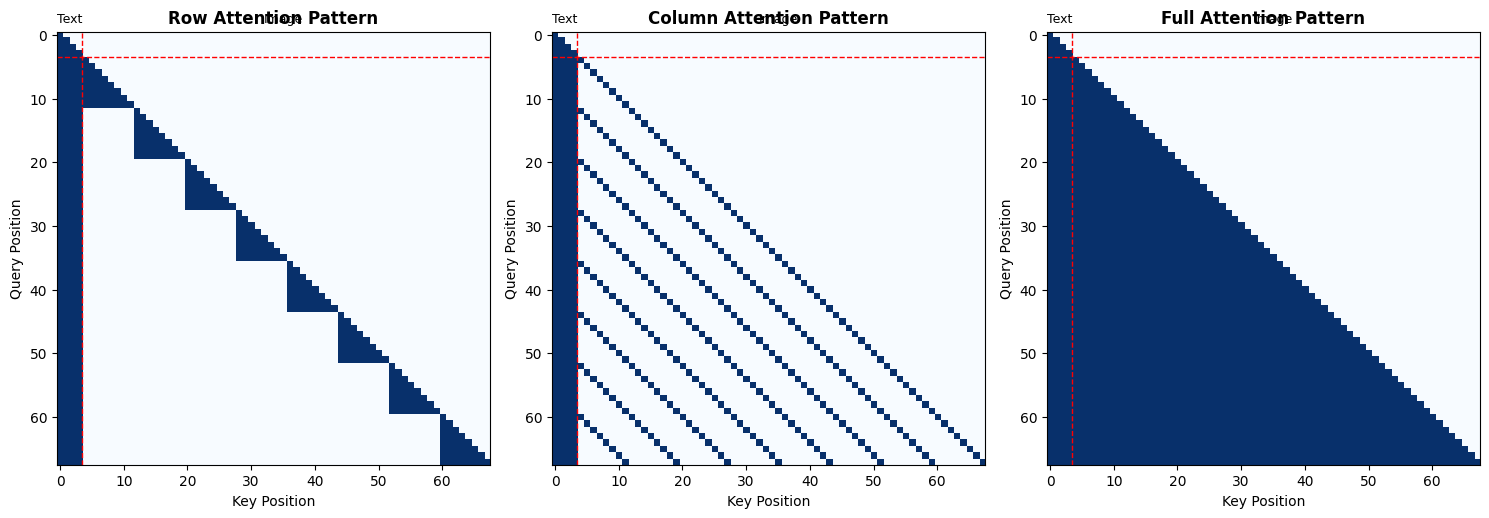


圖片已儲存為 sparse_attention_patterns.png


In [6]:
def create_sparse_attention_mask(
    text_len: int,
    image_size: int,
    pattern: str = 'row'
) -> torch.Tensor:
    """
    創建稀疏注意力遮罩
    
    Args:
        text_len: 文字 token 數量
        image_size: 圖像 token 的邊長（假設正方形）
        pattern: 'row', 'column', 或 'full'
        
    Returns:
        [total_len, total_len] 的注意力遮罩（1=可注意，0=不可注意）
    """
    image_len = image_size * image_size
    total_len = text_len + image_len
    
    mask = torch.zeros(total_len, total_len)
    
    # 1. 文字 token 之間：因果遮罩
    mask[:text_len, :text_len] = torch.tril(torch.ones(text_len, text_len))
    
    # 2. 圖像 token 可以看到所有文字 token
    mask[text_len:, :text_len] = 1
    
    # 3. 圖像 token 之間的稀疏模式
    for i in range(image_len):
        row_i, col_i = i // image_size, i % image_size
        for j in range(i + 1):  # 因果：只能看到之前的 token
            row_j, col_j = j // image_size, j % image_size
            
            if pattern == 'row':
                # 只注意同一行的 token
                if row_i == row_j:
                    mask[text_len + i, text_len + j] = 1
            elif pattern == 'column':
                # 只注意同一列的 token
                if col_i == col_j:
                    mask[text_len + i, text_len + j] = 1
            else:  # full
                mask[text_len + i, text_len + j] = 1
    
    return mask

# 視覺化稀疏注意力模式
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, pattern in zip(axes, ['row', 'column', 'full']):
    mask = create_sparse_attention_mask(text_len=4, image_size=8, pattern=pattern)
    im = ax.imshow(mask, cmap='Blues', aspect='equal')
    ax.set_title(f'{pattern.capitalize()} Attention Pattern', fontsize=12, fontweight='bold')
    ax.set_xlabel('Key Position', fontsize=10)
    ax.set_ylabel('Query Position', fontsize=10)
    
    # 標記文字和圖像區域
    ax.axhline(y=3.5, color='red', linestyle='--', linewidth=1)
    ax.axvline(x=3.5, color='red', linestyle='--', linewidth=1)
    ax.text(1.5, -2, 'Text', ha='center', fontsize=9)
    ax.text(35, -2, 'Image', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('sparse_attention_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n圖片已儲存為 sparse_attention_patterns.png")

## 6. 帶稀疏注意力的 Transformer 層

In [7]:
class SparseAttention(nn.Module):
    """
    帶稀疏遮罩的多頭自注意力
    """
    def __init__(
        self,
        dim: int,
        num_heads: int = 8,
        dropout: float = 0.1
    ):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        
        self.qkv = nn.Linear(dim, 3 * dim)
        self.proj = nn.Linear(dim, dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, attention_mask=None):
        """
        Args:
            x: [batch, seq_len, dim]
            attention_mask: [seq_len, seq_len] 或 [batch, seq_len, seq_len]
            
        Returns:
            [batch, seq_len, dim]
        """
        batch, seq_len, _ = x.shape
        
        # 計算 Q, K, V
        qkv = self.qkv(x).reshape(batch, seq_len, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # [3, batch, heads, seq_len, head_dim]
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        # 計算注意力分數
        attn = (q @ k.transpose(-2, -1)) * self.scale
        
        # 應用稀疏遮罩
        if attention_mask is not None:
            if attention_mask.dim() == 2:
                attention_mask = attention_mask.unsqueeze(0).unsqueeze(0)
            attn = attn.masked_fill(attention_mask == 0, float('-inf'))
        
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)
        
        # 應用注意力
        out = (attn @ v).transpose(1, 2).reshape(batch, seq_len, -1)
        return self.proj(out)


class TransformerBlock(nn.Module):
    """
    Transformer Block，支援稀疏注意力
    """
    def __init__(
        self,
        dim: int,
        num_heads: int = 8,
        mlp_ratio: float = 4.0,
        dropout: float = 0.1
    ):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = SparseAttention(dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(dim * mlp_ratio), dim),
            nn.Dropout(dropout)
        )
        
    def forward(self, x, attention_mask=None):
        x = x + self.attn(self.norm1(x), attention_mask)
        x = x + self.mlp(self.norm2(x))
        return x

# 測試
block = TransformerBlock(dim=256, num_heads=8)
mask = create_sparse_attention_mask(text_len=8, image_size=4, pattern='row')
x = torch.randn(2, 24, 256)  # 8 text + 16 image tokens
output = block(x, mask)
print(f"Transformer Block 輸出形狀: {output.shape}")

Transformer Block 輸出形狀: torch.Size([2, 24, 256])


## 7. 自迴歸採樣

In [8]:
def top_k_sampling(logits, k=50, temperature=1.0):
    """
    Top-k 採樣
    
    只從機率最高的 k 個 token 中採樣
    """
    # 縮放 logits
    logits = logits / temperature
    
    # 找到 top-k
    top_k_logits, top_k_indices = torch.topk(logits, k, dim=-1)
    
    # 在 top-k 上做 softmax
    probs = F.softmax(top_k_logits, dim=-1)
    
    # 採樣
    sampled_idx = torch.multinomial(probs, num_samples=1)
    
    # 映射回原始索引
    return torch.gather(top_k_indices, -1, sampled_idx).squeeze(-1)


def nucleus_sampling(logits, p=0.9, temperature=1.0):
    """
    Nucleus (Top-p) 採樣
    
    選擇累積機率達到 p 的最小 token 集合
    """
    # 縮放 logits
    logits = logits / temperature
    probs = F.softmax(logits, dim=-1)
    
    # 排序
    sorted_probs, sorted_indices = torch.sort(probs, descending=True, dim=-1)
    cumsum_probs = torch.cumsum(sorted_probs, dim=-1)
    
    # 找到累積機率超過 p 的位置
    mask = cumsum_probs - sorted_probs > p
    sorted_probs[mask] = 0.0
    
    # 重新正規化
    sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)
    
    # 採樣
    sampled_idx = torch.multinomial(sorted_probs, num_samples=1)
    
    # 映射回原始索引
    return torch.gather(sorted_indices, -1, sampled_idx).squeeze(-1)


# 測試採樣方法
test_logits = torch.randn(2, 1000)  # 模擬 1000 個 token 的 logits

print("Top-k 採樣 (k=50):")
for _ in range(5):
    sampled = top_k_sampling(test_logits, k=50, temperature=0.9)
    print(f"  採樣的 token 索引: {sampled.tolist()}")

print("\nNucleus 採樣 (p=0.9):")
for _ in range(5):
    sampled = nucleus_sampling(test_logits, p=0.9, temperature=0.9)
    print(f"  採樣的 token 索引: {sampled.tolist()}")

Top-k 採樣 (k=50):
  採樣的 token 索引: [702, 772]
  採樣的 token 索引: [269, 632]
  採樣的 token 索引: [544, 21]
  採樣的 token 索引: [688, 187]
  採樣的 token 索引: [737, 106]

Nucleus 採樣 (p=0.9):
  採樣的 token 索引: [443, 829]
  採樣的 token 索引: [786, 29]
  採樣的 token 索引: [261, 622]
  採樣的 token 索引: [487, 959]
  採樣的 token 索引: [840, 515]


## 8. 簡化版 DALL-E 模型

In [9]:
class SimplifiedDALLE(nn.Module):
    """
    簡化版的 DALL-E 模型
    
    包含：
    1. 文字 embedding
    2. 圖像 token embedding
    3. 自迴歸 Transformer
    4. 輸出預測頭
    """
    def __init__(
        self,
        vocab_size: int = 16384,      # 文字詞彙表大小
        num_image_tokens: int = 8192,  # 圖像 token 數量
        max_text_len: int = 256,       # 最大文字長度
        image_size: int = 32,          # 圖像 token 邊長
        dim: int = 512,                # 模型維度
        num_layers: int = 12,          # Transformer 層數
        num_heads: int = 8             # 注意力頭數
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.num_image_tokens = num_image_tokens
        self.max_text_len = max_text_len
        self.image_size = image_size
        self.total_tokens = vocab_size + num_image_tokens
        
        # Token embeddings（文字和圖像使用同一個 embedding）
        self.token_embedding = nn.Embedding(self.total_tokens, dim)
        
        # 位置 embeddings
        max_seq_len = max_text_len + image_size * image_size
        self.position_embedding = nn.Embedding(max_seq_len, dim)
        
        # Transformer layers
        self.layers = nn.ModuleList([
            TransformerBlock(dim, num_heads)
            for _ in range(num_layers)
        ])
        
        # 輸出投影
        self.ln_final = nn.LayerNorm(dim)
        self.lm_head = nn.Linear(dim, self.total_tokens, bias=False)
        
    def forward(self, text_tokens, image_tokens=None, attention_mask=None):
        """
        Args:
            text_tokens: [batch, text_len] 文字 token 索引
            image_tokens: [batch, image_len] 圖像 token 索引（可選，訓練時提供）
            attention_mask: 注意力遮罩（可選）
            
        Returns:
            logits: [batch, seq_len, total_tokens]
        """
        batch = text_tokens.shape[0]
        device = text_tokens.device
        
        # 圖像 token 需要加上 vocab_size 的偏移
        if image_tokens is not None:
            image_tokens = image_tokens + self.vocab_size
            tokens = torch.cat([text_tokens, image_tokens], dim=1)
        else:
            tokens = text_tokens
        
        seq_len = tokens.shape[1]
        
        # Embeddings
        token_emb = self.token_embedding(tokens)
        positions = torch.arange(seq_len, device=device).unsqueeze(0)
        pos_emb = self.position_embedding(positions)
        
        x = token_emb + pos_emb
        
        # Transformer layers
        for layer in self.layers:
            x = layer(x, attention_mask)
        
        x = self.ln_final(x)
        logits = self.lm_head(x)
        
        return logits
    
    @torch.no_grad()
    def generate_image_tokens(
        self,
        text_tokens: torch.Tensor,
        temperature: float = 1.0,
        top_k: int = 100
    ) -> torch.Tensor:
        """
        自迴歸生成圖像 token
        
        Args:
            text_tokens: [batch, text_len] 文字 token
            temperature: 採樣溫度
            top_k: top-k 採樣的 k 值
            
        Returns:
            [batch, image_size * image_size] 圖像 token
        """
        batch = text_tokens.shape[0]
        device = text_tokens.device
        num_image_tokens = self.image_size * self.image_size
        
        # 初始化圖像 token
        generated = torch.empty(batch, 0, dtype=torch.long, device=device)
        
        for _ in range(num_image_tokens):
            # 獲得 logits
            logits = self.forward(text_tokens, generated if generated.shape[1] > 0 else None)
            
            # 取最後一個位置的 logits（只預測圖像 token）
            next_logits = logits[:, -1, self.vocab_size:]  # 只考慮圖像 token
            
            # Top-k 採樣
            next_token = top_k_sampling(next_logits, k=top_k, temperature=temperature)
            next_token = next_token.unsqueeze(1)
            
            # 添加到生成序列
            generated = torch.cat([generated, next_token], dim=1)
        
        return generated

# 測試簡化版 DALL-E
model = SimplifiedDALLE(
    vocab_size=1000,
    num_image_tokens=512,
    max_text_len=32,
    image_size=8,
    dim=256,
    num_layers=4,
    num_heads=8
)

# 模擬文字輸入
text_tokens = torch.randint(0, 1000, (2, 20))
image_tokens = torch.randint(0, 512, (2, 64))  # 8x8 = 64 圖像 tokens

# 訓練時的前向傳播
logits = model(text_tokens, image_tokens)
print(f"訓練時輸出形狀: {logits.shape}")

# 生成圖像 token
print("\n正在生成圖像 token...")
generated = model.generate_image_tokens(text_tokens, temperature=0.9, top_k=50)
print(f"生成的圖像 token 形狀: {generated.shape}")
print(f"前 10 個生成的 token: {generated[0, :10].tolist()}")

訓練時輸出形狀: torch.Size([2, 84, 1512])

正在生成圖像 token...
生成的圖像 token 形狀: torch.Size([2, 64])
前 10 個生成的 token: [452, 74, 391, 14, 249, 117, 228, 65, 90, 287]


## 9. 視覺化：溫度對採樣的影響

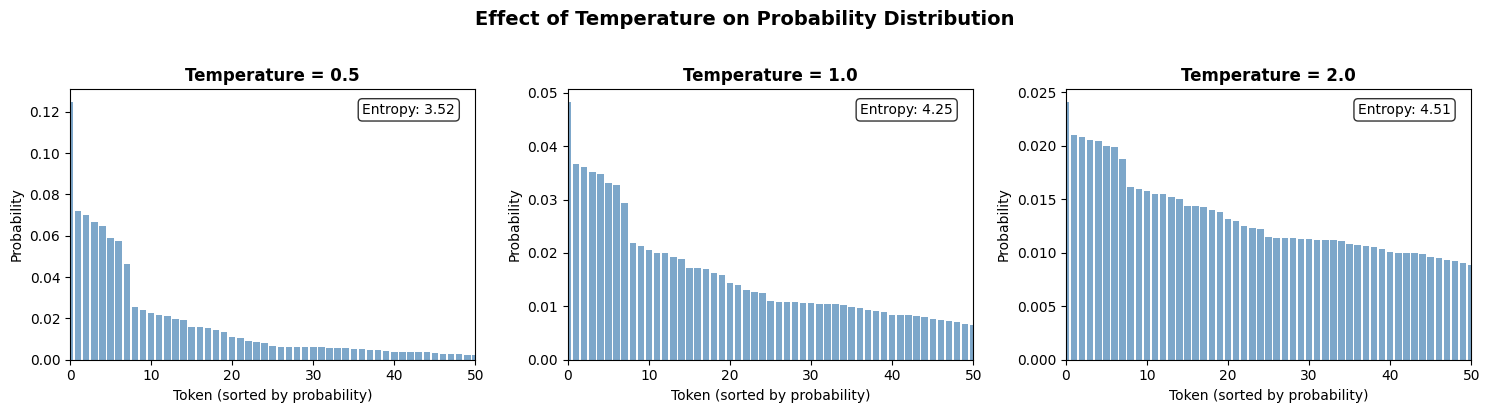


圖片已儲存為 temperature_effect.png

觀察：
- 低溫度 (0.5)：分布更尖銳，更確定，傾向選擇最高機率的 token
- 高溫度 (2.0)：分布更平坦，更多樣，更可能選擇低機率的 token


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 創建一些模擬的 logits
np.random.seed(42)
logits = torch.tensor(np.random.randn(100))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

temperatures = [0.5, 1.0, 2.0]
for ax, temp in zip(axes, temperatures):
    probs = F.softmax(logits / temp, dim=-1).numpy()
    sorted_probs = np.sort(probs)[::-1]
    
    ax.bar(range(len(sorted_probs)), sorted_probs, color='steelblue', alpha=0.7)
    ax.set_title(f'Temperature = {temp}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Token (sorted by probability)', fontsize=10)
    ax.set_ylabel('Probability', fontsize=10)
    ax.set_xlim(0, 50)  # 只顯示前 50 個
    
    # 計算熵
    entropy = -np.sum(probs * np.log(probs + 1e-10))
    ax.text(0.95, 0.95, f'Entropy: {entropy:.2f}', transform=ax.transAxes, 
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Effect of Temperature on Probability Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('temperature_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n圖片已儲存為 temperature_effect.png")
print("\n觀察：")
print("- 低溫度 (0.5)：分布更尖銳，更確定，傾向選擇最高機率的 token")
print("- 高溫度 (2.0)：分布更平坦，更多樣，更可能選擇低機率的 token")

## 10. 總結

本 notebook 實作了 DALL-E 的核心組件：

1. **Gumbel-Softmax**：
   - 讓離散化操作可微分
   - 溫度參數控制分布的尖銳程度
   - Straight-through estimator 用於訓練

2. **Discrete VAE (dVAE)**：
   - 編碼器：圖像 → 離散 token
   - 解碼器：離散 token → 圖像
   - 壓縮率約 192×

3. **稀疏注意力**：
   - Row attention：同一行的 token 互相注意
   - Column attention：同一列的 token 互相注意
   - 降低計算複雜度

4. **自迴歸採樣**：
   - Top-k 採樣
   - Nucleus (Top-p) 採樣
   - 溫度控制

### 與完整 DALL-E 的差異

| 特性 | 本 notebook | 完整 DALL-E |
|------|-------------|-------------|
| 參數量 | ~數百萬 | 120 億 |
| 圖像解析度 | 64×64 | 256×256 |
| Codebook 大小 | 512 | 8192 |
| Transformer 層數 | 4-12 | 64 |
| 訓練資料 | 無 | 2.5 億對 |

### 實際使用建議

對於實際的文字到圖像生成，建議使用：
- **DALL-E 3**：最新版本，整合到 ChatGPT
- **Stable Diffusion**：開源，可本地運行
- **Midjourney**：高品質藝術風格

這些模型已經在大規模資料上訓練，可以生成高品質的圖像。